# Task 2: Credit Risk Prediction

**Internship:** DevelopersHub Corporation — Data Science & Analytics  
**Name:** Muneeb Ur Rehman  
**Email:** mu181842@gmail.com  
**GitHub:** https://github.com/muneeb-914/credit-risk-prediction

---

## Problem Statement
Banks need to assess the risk of giving loans to applicants. Approving a loan for someone who will default costs the bank money. Rejecting a good applicant means losing business.

In this task, we build a **binary classification model** to predict whether a loan applicant will be approved or rejected based on personal and financial information.

---

## Dataset Description
| Property | Value |
|----------|-------|
| Source | Kaggle — Loan Prediction Dataset |
| Rows | 614 |
| Columns | 13 |
| Target | Loan_Status (Y/N) |
| Missing Values | Yes — 7 columns |

**Key Features:**
- **ApplicantIncome** — Monthly income of applicant
- **LoanAmount** — Requested loan amount
- **Credit_History** — Whether applicant has credit history (1/0)
- **Education** — Graduate or Not Graduate
- **Property_Area** — Urban, Rural, Semiurban

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('raw_data/train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Step 1: Missing Value Analysis
Identifying columns with missing data and deciding the best strategy to fill them — median for numerical, mode for categorical.

In [4]:
print('Shape:', df.shape)
print('\nColumns:',df.columns.tolist())
print('\nMissing values:\n', df.isnull().sum())
print("\nLoan Status Distribution:")
print(df['Loan_Status'].value_counts())
print('\nStatistical summary:\n', df.describe())

Shape: (614, 13)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Missing values:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Loan Status Distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Statistical summary:
        ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000 

In [5]:
# Fill numerical columns with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace=True)
df['Credit_History'].fillna(df['Credit_History'].median(), inplace=True)

# Fill categorical columns with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

# Confirm
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


C:\Users\ML\AppData\Local\Temp\ipykernel_2600\274089439.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
C:\Users\ML\AppData\Local\Temp\ipykernel_2600\274089439.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

## Step 2: Exploratory Data Analysis (EDA)
Visualizing key features to understand their relationship with loan approval status.

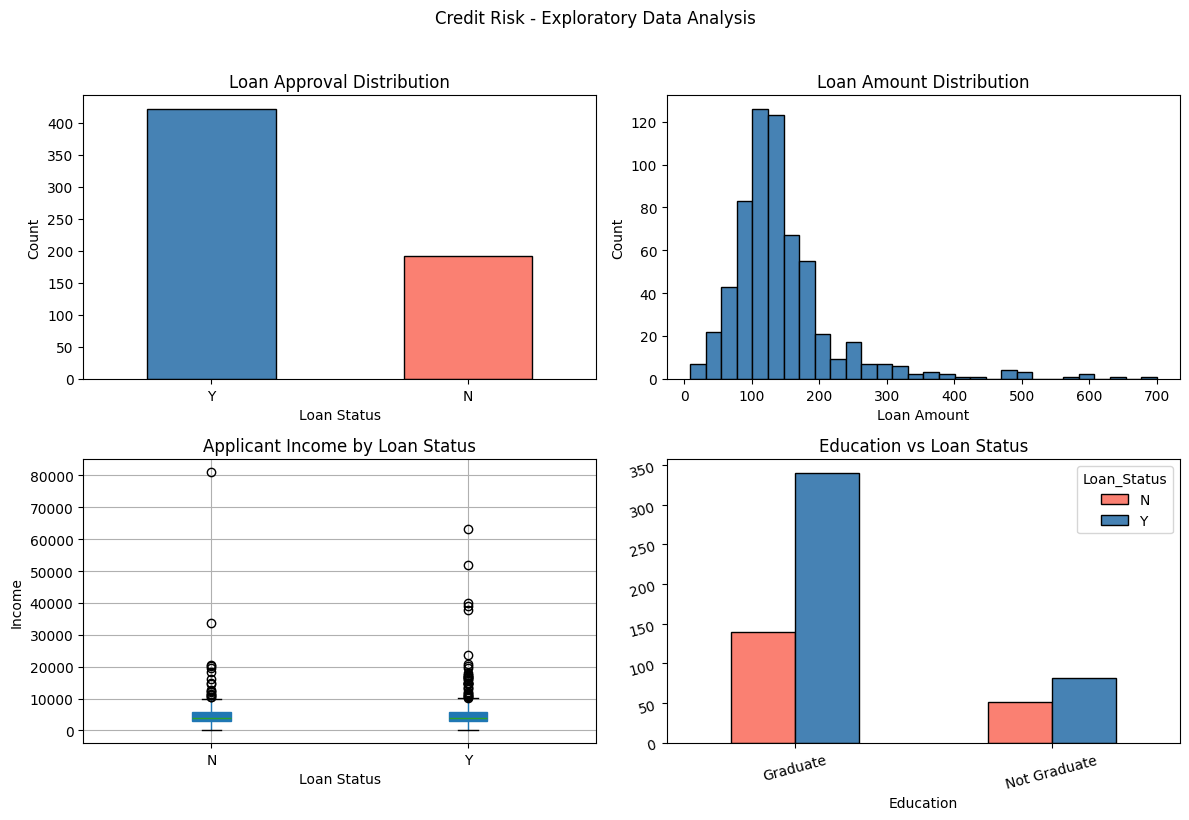

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Loan Status Count
df['Loan_Status'].value_counts().plot(kind='bar', ax=axes[0,0], 
                                      color=['steelblue', 'salmon'], edgecolor='black')
axes[0,0].set_title('Loan Approval Distribution')
axes[0,0].set_xlabel('Loan Status')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(rotation=0)

# Loan Amount Distribution
axes[0,1].hist(df['LoanAmount'], bins=30, color='steelblue', edgecolor='black')
axes[0,1].set_title('Loan Amount Distribution')
axes[0,1].set_xlabel('Loan Amount')
axes[0,1].set_ylabel('Count')

# Applicant Income vs Loan Status
df.boxplot(column='ApplicantIncome', by='Loan_Status', ax=axes[1,0], 
           patch_artist=True)
axes[1,0].set_title('Applicant Income by Loan Status')
axes[1,0].set_xlabel('Loan Status')
axes[1,0].set_ylabel('Income')

# Education vs Loan Status
edu_loan = df.groupby(['Education', 'Loan_Status']).size().unstack()
edu_loan.plot(kind='bar', ax=axes[1,1], color=['salmon', 'steelblue'], 
              edgecolor='black')
axes[1,1].set_title('Education vs Loan Status')
axes[1,1].set_xlabel('Education')
axes[1,1].tick_params(rotation=15)

plt.suptitle('Credit Risk - Exploratory Data Analysis', y=1.02)
plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150)
plt.show()

## Step 3: Feature Engineering & Model Training
Encoding categorical variables, scaling features, and training a Logistic Regression classifier.

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 
            'Self_Employed', 'Property_Area', 'Loan_Status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

print("Model trained!")
print(f"Train: {len(X_train)} samples, Test: {len(X_test)} samples")

Model trained!
Train: 491 samples, Test: 123 samples


## Step 4: Model Evaluation
Measuring model performance using accuracy score, classification report, and confusion matrix.

Accuracy: 78.86%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



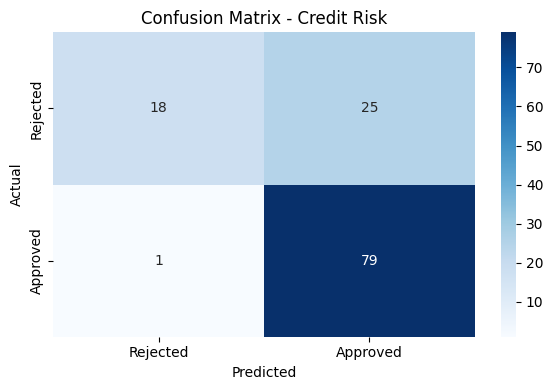

In [10]:
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confusion Matrix - Credit Risk')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

## Conclusion & Key Insights

### Model Performance:
- **Accuracy: 78.86%** on 123 test samples
- Strong at identifying approvals (recall 0.99)
- Weaker at identifying rejections (recall 0.42) — due to class imbalance

### Business Insights:
1. **25 false positives** — applicants approved who may default. This is a real financial risk for the bank
2. **Income alone doesn't determine approval** — both approved and rejected have similar income distributions
3. **Graduates get approved more** — education is a strong factor
4. **Credit history is critical** — 50 missing values suggests many applicants have no credit history

### Recommendation:
To improve rejection detection, future work should balance the dataset using SMOTE and test Random Forest or Decision Tree models.

### Technologies Used
- **Python** — Programming language
- **Pandas** — Data manipulation
- **Scikit-learn** — Logistic Regression, StandardScaler, LabelEncoder
- **Matplotlib & Seaborn** — Visualizations